<a href="https://colab.research.google.com/github/abdullahasas15/Wine-Quality-Prediction/blob/main/Wine-Quality-Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['Unnamed: 0', 'City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
       'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI',
       'AQI_Bucket'],
      dtype='object')
   Unnamed: 0       City       Date      PM2.5        PM10     NO    NO2  \
0           0  Ahmedabad 2015-01-01  67.450578  118.127103   0.92  18.22   
1           1  Ahmedabad 2015-01-02  67.450578  118.127103   0.97  15.69   
2           2  Ahmedabad 2015-01-03  67.450578  118.127103  17.40  19.30   
3           3  Ahmedabad 2015-01-04  67.450578  118.127103   1.70  18.48   
4           4  Ahmedabad 2015-01-05  67.450578  118.127103  22.10  21.42   

     NOx        NH3     CO    SO2      O3  Benzene  Toluene  Xylene  \
0  17.15  23.483476   0.92  27.64  133.36     0.00     0.02    0.00   
1  16.46  23.483476   0.97  24.55   34.06     3.68     5.50    3.77   
2  29.70  23.483476  17.40  29.07   30.70     6.80    16.40    2.25   
3  17.97  23.483476   1.70  18.59   36.08     4.43    10.14    1.00  

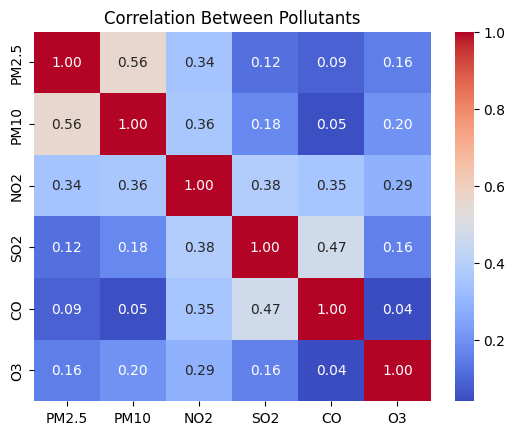

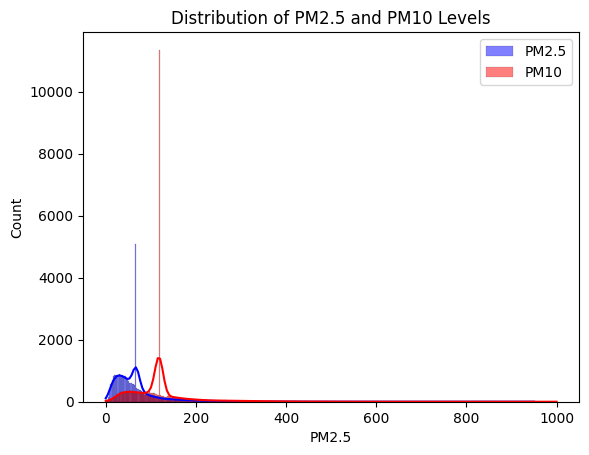

        City  PM2.5_Zscore  PM10_Zscore
0  Ahmedabad           0.0          0.0
1  Ahmedabad           0.0          0.0
2  Ahmedabad           0.0          0.0
3  Ahmedabad           0.0          0.0
4  Ahmedabad           0.0          0.0


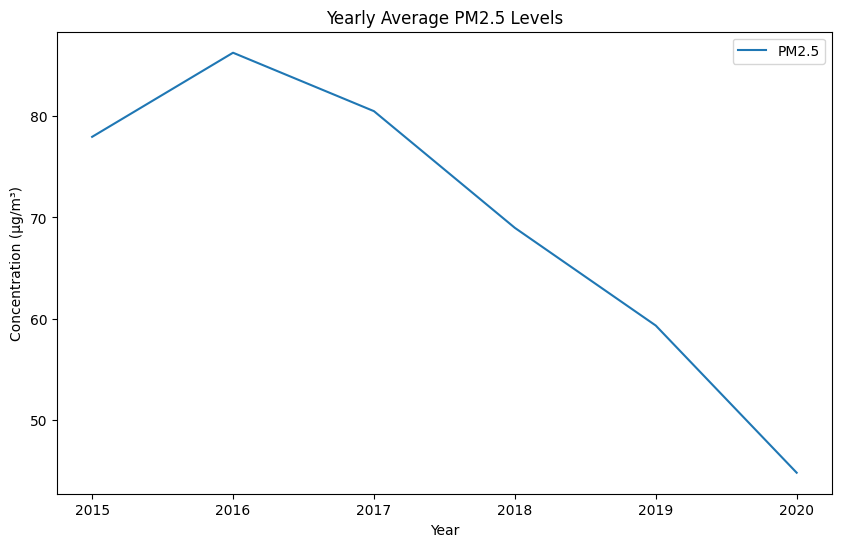

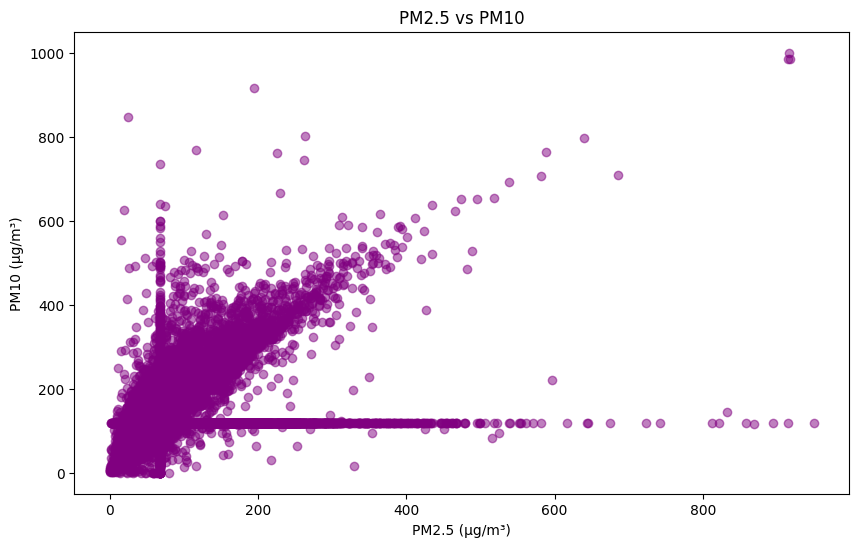

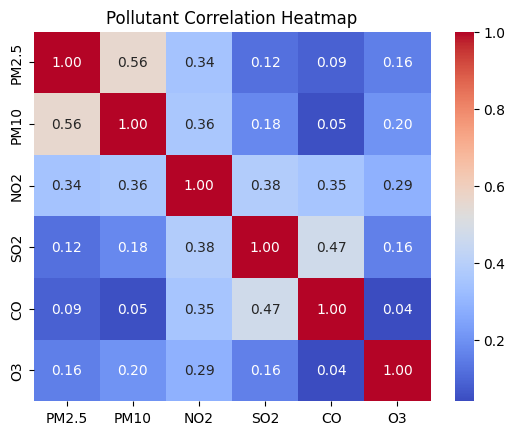

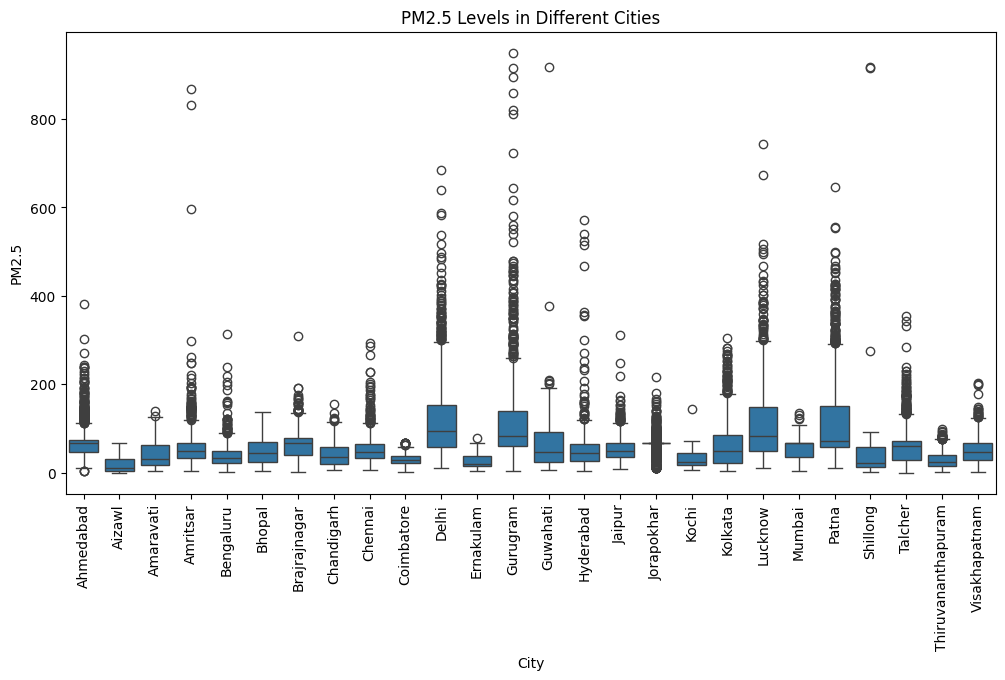

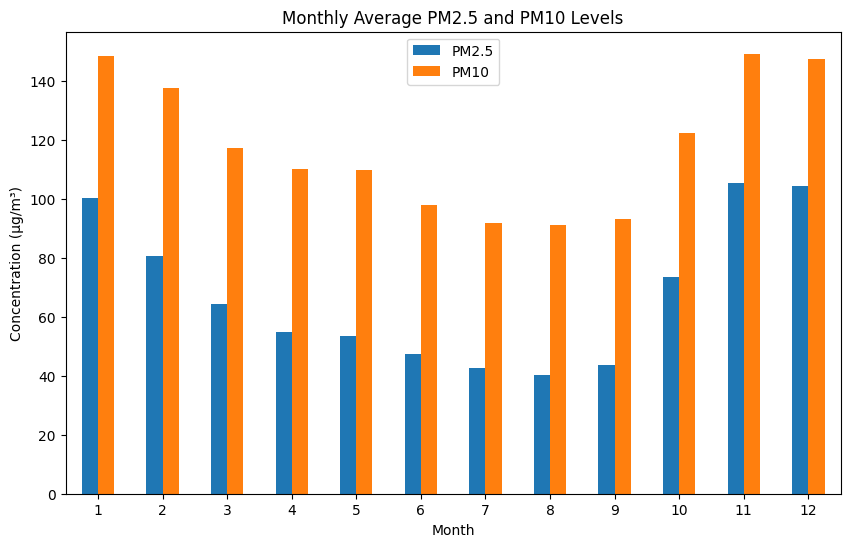

Northern Cities Average Pollution Levels:
PM2.5    107.326407
PM10     209.651019
dtype: float64

Southern Cities Average Pollution Levels:
PM2.5   NaN
PM10    NaN
dtype: float64


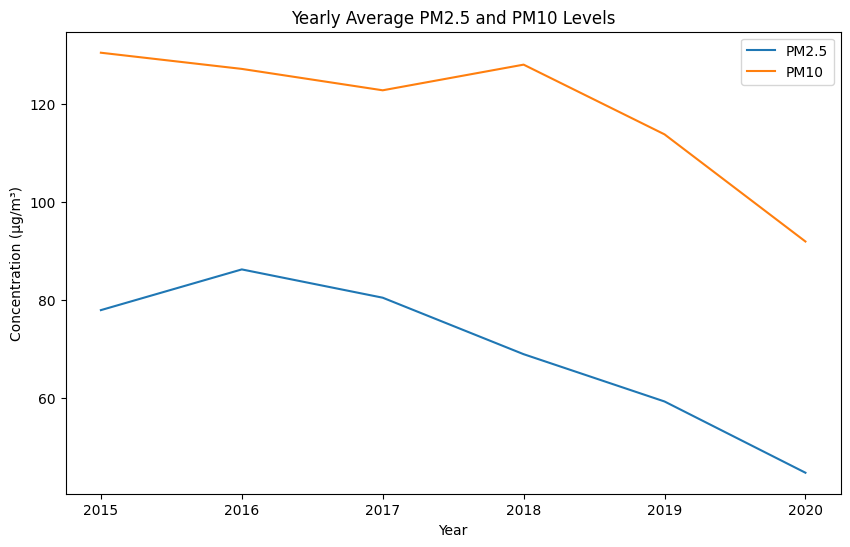

            City       Date   PM2.5
667    Ahmedabad 2016-10-29  381.69
669    Ahmedabad 2016-10-31  271.85
1280   Ahmedabad 2018-07-04  302.08
3141    Amritsar 2017-05-06  296.84
3143    Amritsar 2017-05-08  868.66
...          ...        ...     ...
25730   Shillong 2019-09-04  274.92
26106    Talcher 2018-03-04  283.31
26122    Talcher 2018-03-20  331.81
26797    Talcher 2020-01-24  342.42
26798    Talcher 2020-01-25  354.44

[572 rows x 3 columns]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/mimansha98/AQI-Prediction-before-and-after-Lockdown-of-COVID-19-in-India/main/city_day.csv')

# Check the column names to ensure they match the dataset
print(df.columns)

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Handle any invalid date entries

# Inspect the first few rows of the dataset
print(df.head())

# Fill missing values with median for numerical columns
# Fill missing values **only** in numeric columns using median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


# Create NumPy arrays for PM2.5 and PM10
pm25_array = np.array(df['PM2.5'])
pm10_array = np.array(df['PM10'])

# Array indexing and slicing
print(pm25_array[:10])  # Print first 10 values of PM2.5
print(pm25_array[10:20])  # Print values from 10 to 20 of PM2.5

# Reshaping arrays (e.g., reshape to 2D array)
reshaped_pm25 = pm25_array.reshape(-1, 1)

# Concatenating PM2.5 and PM10 arrays
pollution_data = np.concatenate((pm25_array.reshape(-1, 1), pm10_array.reshape(-1, 1)), axis=1)

# Sorting PM2.5 array
sorted_pm25 = np.sort(pm25_array)


# Calculate the average PM2.5 and PM10 levels per city
avg_pollution = df.groupby('City')[['PM2.5', 'PM10']].mean()
print(avg_pollution)

# Handle missing data (already filled with median in earlier step)

# Aggregation and grouping by city to get the mean pollution levels
city_pollution = df.groupby('City')[['PM2.5', 'PM10']].mean()
print(city_pollution)

# Pivot Table: Show average PM2.5 and PM10 by year and city
df['Year'] = df['Date'].dt.year
pivot_table = df.pivot_table(values=['PM2.5', 'PM10'], index='Year', columns='City', aggfunc='mean')
print(pivot_table)

# ---Inferential Statistics---

# Correlation between pollutants
correlation_matrix = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Pollutants')
plt.show()

# Distribution of PM2.5 and PM10 (Visualizing the statistical distribution)
sns.histplot(df['PM2.5'], kde=True, color='blue', label='PM2.5')
sns.histplot(df['PM10'], kde=True, color='red', label='PM10')
plt.legend()
plt.title('Distribution of PM2.5 and PM10 Levels')
plt.show()

# Z-score calculation for PM2.5 and PM10
from scipy.stats import zscore
df['PM2.5_Zscore'] = zscore(df['PM2.5'])
df['PM10_Zscore'] = zscore(df['PM10'])
print(df[['City', 'PM2.5_Zscore', 'PM10_Zscore']].head())

# ---Visualization with Matplotlib and Seaborn---

# Line Plot: Show trend of PM2.5 levels over the years
yearly_avg = df.groupby('Year')[['PM2.5']].mean()
yearly_avg.plot(figsize=(10, 6))
plt.title('Yearly Average PM2.5 Levels')
plt.ylabel('Concentration (µg/m³)')
plt.show()

# Scatter Plot: PM2.5 vs PM10 for each city
plt.figure(figsize=(10, 6))
plt.scatter(df['PM2.5'], df['PM10'], alpha=0.5, c='purple')
plt.title('PM2.5 vs PM10')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('PM10 (µg/m³)')
plt.show()

# Heatmap: Correlation between pollutants
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pollutant Correlation Heatmap')
plt.show()

# Box Plot: PM2.5 levels in different cities
plt.figure(figsize=(12, 6))
sns.boxplot(x='City', y='PM2.5', data=df)
plt.xticks(rotation=90)
plt.title('PM2.5 Levels in Different Cities')
plt.show()

# Seasonal Variation of PM2.5 and PM10 (Month-wise)
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[['PM2.5', 'PM10']].mean()
monthly_avg.plot(kind='bar', figsize=(10, 6))
plt.title('Monthly Average PM2.5 and PM10 Levels')
plt.ylabel('Concentration (µg/m³)')
plt.xticks(rotation=0)
plt.show()

# Analysis of Pollution in Northern vs Southern cities (assuming state column exists)
north_cities = df[df['City'].isin(['Jammu & Kashmir', 'Himachal Pradesh', 'Punjab', 'Uttarakhand', 'Uttar Pradesh', 'Bihar', 'Madhya Pradesh', 'Rajasthan', 'Haryana', 'Delhi', 'Chandigarh', 'Uttarakhand', 'Jharkhand', 'West Bengal'])]
south_cities = df[df['City'].isin(['Goa', 'Maharashtra', 'Gujarat', 'Karnataka', 'Kerala', 'Tamil Nadu', 'Andhra Pradesh', 'Telangana', 'Odisha', 'Chhattisgarh', 'Lakshadweep', 'Andaman & Nicobar Islands'])]

north_avg = north_cities[['PM2.5', 'PM10']].mean()
south_avg = south_cities[['PM2.5', 'PM10']].mean()

print("Northern Cities Average Pollution Levels:")
print(north_avg)
print("\nSouthern Cities Average Pollution Levels:")
print(south_avg)

# Trends of PM2.5 and PM10 over the years (Yearly trend)
yearly_avg = df.groupby('Year')[['PM2.5', 'PM10']].mean()
yearly_avg.plot(figsize=(10, 6))
plt.title('Yearly Average PM2.5 and PM10 Levels')
plt.ylabel('Concentration (µg/m³)')
plt.show()

# Identifying cities prone to severe pollution events (PM2.5 > 250)
severe_pollution = df[df['PM2.5'] > 250]  # Threshold can be adjusted
print(severe_pollution[['City', 'Date', 'PM2.5']])

In [ ]:
df1 = pd.DataFrame({'A': ['A0', 'A1']}, index=[0, 1])
df2 = pd.DataFrame({'A': ['A2', 'A3']}, index=[0, 1])
pd.concat([df1, df2],verify_integrity=False)

,A
0,A0
1,A1
0,A2
1,A3


In [ ]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
data = sns.load_dataset('titanic')
pivot = pd.pivot_table(data, index='sex', columns='class', values='survived', aggfunc='mean')
print(pivot)

class      First    Second     Third
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


<ipython-input-60-eb18a7af3ce5>:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(data, index='sex', columns='class', values='survived', aggfunc='mean')


In [ ]:
data['age_bin'] = pd.cut(data['age'], bins=[0, 18, 40, 60, 80])
print(data.head())
data['fare_bin'] = pd.qcut(data['fare'], q=4)

pivot = pd.pivot_table(data, index='sex', columns='age_bin', values='survived', aggfunc='mean')
print(pivot)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone   age_bin         fare_bin  
0    man        True  NaN  Southampton    no  False  (18, 40]   (-0.001, 7.91]  
1  woman       False    C    Cherbourg   yes  False  (18, 40]  (31.0, 512.329]  
2  woman       False  NaN  Southampton   yes   True  (18, 40]   (7.91, 14.454]  
3  woman       False    C  Southampton   yes  False  (18, 40]  (31.0, 512.329]  
4    man        True  NaN  Southampton    no   True  (18, 40]   (7.91, 14.454]  
age_bin   (0, 18]  (18, 40]  (40, 60]  (60, 80]
sex      

<ipython-input-62-bafd6f681498>:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(data, index='sex', columns='age_bin', values='survived', aggfunc='mean')


In [ ]:
births = pd.read_csv("https://raw.githubusercontent.com/jakevdp/data-CDCbirths/master/births.csv")
births['decade'] = 10 * (births['year'] // 10)
print(births.head())
births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')

   year  month  day gender  births  decade
0  1969      1  1.0      F    4046    1960
1  1969      1  1.0      M    4440    1960
2  1969      1  2.0      F    4454    1960
3  1969      1  2.0      M    4548    1960
4  1969      1  3.0      F    4548    1960


gender,F,M
decade,,
1960,1753634,1846572
1970,16263075,17121550
1980,18310351,19243452
1990,19479454,20420553
2000,18229309,19106428


In [ ]:
df = pd.DataFrame({
    'Date': pd.date_range(start='2023-06-25', end='2023-07-25', freq='D'),
    'Values': [1, 2, 3, 4, 5, 6, 7, 8]
}).set_index('Date')

# Weekly sum
weekly_sum = df.resample('W').sum()
print(weekly_sum)
"""
            Values
Date
2023-07-02      36
"""

# Monthly mean
monthly_mean = df.resample('M').mean()

            Values
Date              
2023-06-25       1
2023-07-02      35


<ipython-input-66-cc4a05aa35d5>:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = df.resample('M').mean()


In [ ]:
# Original weekly data
weekly_df = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', periods=4, freq='W'),
    'Values': [10, 20, 30, 40]
}).set_index('Date')
print(weekly_df)

# Upsample to daily and forward fill
daily_df = weekly_df.resample('D').ffill()
print(daily_df.head(10))

            Values
Date              
2023-01-01      10
2023-01-08      20
2023-01-15      30
2023-01-22      40
            Values
Date              
2023-01-01      10
2023-01-02      10
2023-01-03      10
2023-01-04      10
2023-01-05      10
2023-01-06      10
2023-01-07      10
2023-01-08      20
2023-01-09      20
2023-01-10      20


In [ ]:
# Create period (represents a time span)
p = pd.Period('2023-06', freq='M')
print(p)  # 2023-06

# Convert between types
ts = pd.Timestamp('2023-06-15')
print(ts)
period = ts.to_period('M')
print(period) # 2023-06
timestamp = period.to_timestamp()
print(timestamp)  # 2023-06-01

2023-06
2023-06-15 00:00:00
2023-06
2023-06-01 00:00:00


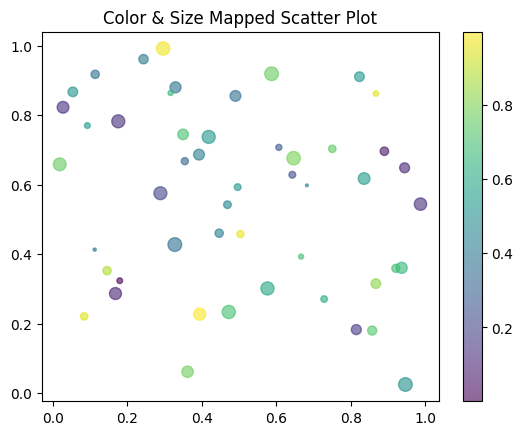

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.random.rand(50)
y = np.random.rand(50)
colors = np.random.rand(50)        # Random colors
sizes = 100 * np.random.rand(50)   # Random sizes

plt.scatter(x, y, c=colors, s=sizes, alpha=0.6, cmap='viridis')
plt.colorbar()                     # Shows color scale
plt.title("Color & Size Mapped Scatter Plot")
plt.show()

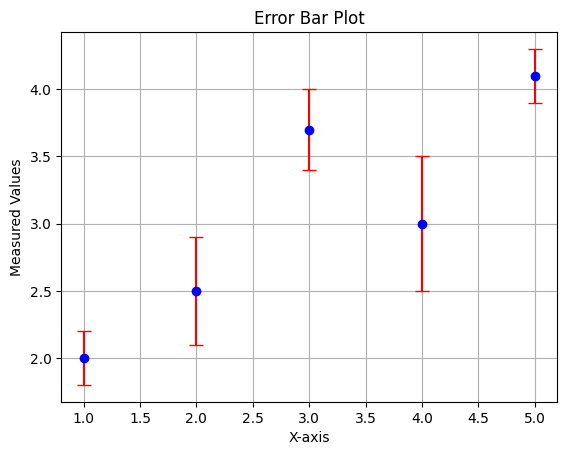

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [2.0, 2.5, 3.7, 3.0, 4.1]
error = [0.2, 0.4, 0.3, 0.5, 0.2]  # Error values for y

plt.errorbar(x, y, yerr=error, fmt='o', capsize=5, color='blue', ecolor='red')
plt.title("Error Bar Plot")
plt.xlabel("X-axis")
plt.ylabel("Measured Values")
plt.grid(True)
plt.show()


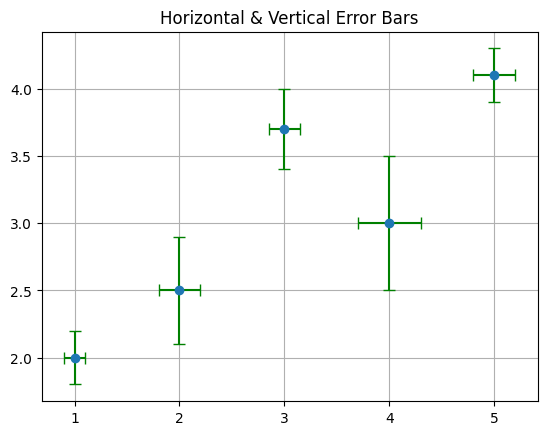

In [ ]:
xerr = [0.1, 0.2, 0.15, 0.3, 0.2]

plt.errorbar(x, y, xerr=xerr, yerr=error, fmt='o', capsize=4, ecolor='green')
plt.title("Horizontal & Vertical Error Bars")
plt.grid(True)
plt.show()


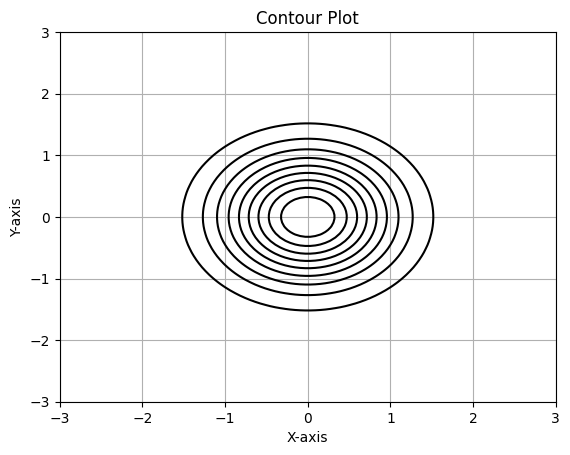

In [ ]:
# Generate a grid of x and y values
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# 2D Gaussian function
Z = np.exp(- (X**2 + Y**2))
plt.contour(X, Y, Z, levels=10, colors='black')  # 10 contour lines
plt.title("Contour Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()

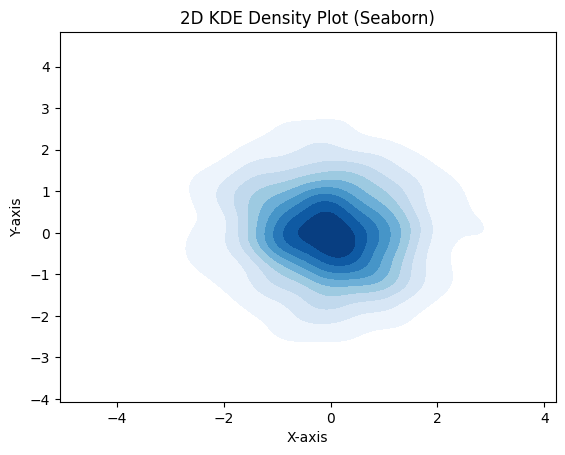

In [ ]:
import seaborn as sns

# Create random 2D data
x = np.random.normal(size=1000)
y = np.random.normal(size=1000)

sns.kdeplot(x=x, y=y, cmap='Blues', fill=True, thresh=0.05)
plt.title("2D KDE Density Plot (Seaborn)")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

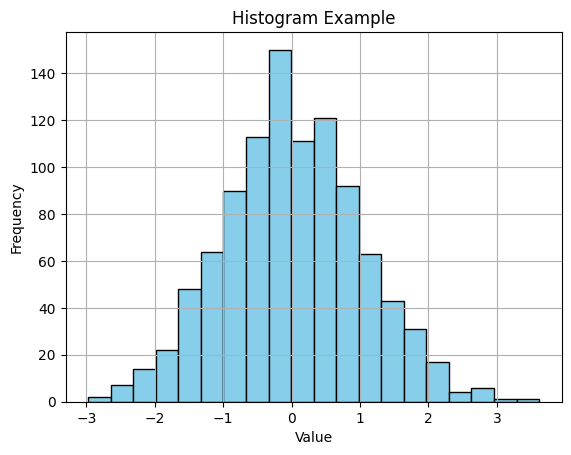

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random data
data = np.random.randn(1000)  # Normally distributed data

# Plot histogram
plt.hist(data, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram Example")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

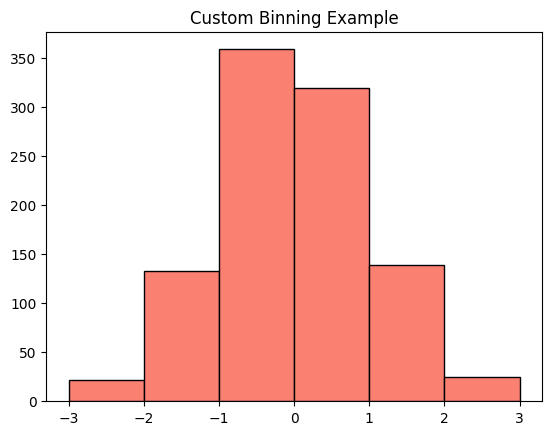

In [ ]:

bins = [-3, -2, -1, 0, 1, 2, 3]  # custom bin edges

plt.hist(data, bins=bins, color='salmon', edgecolor='black')
plt.title("Custom Binning Example")
plt.show()

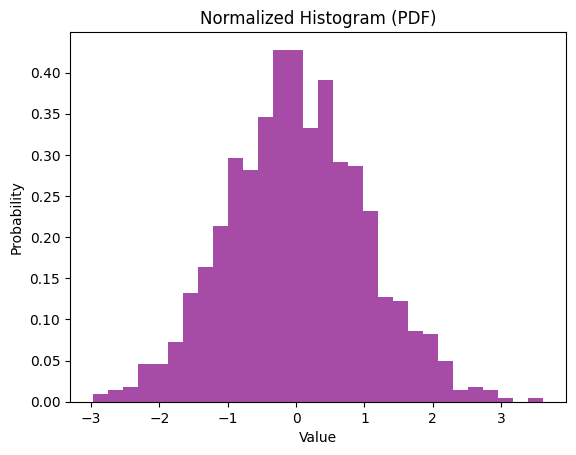

In [ ]:
plt.hist(data, bins=30, density=True, color='purple', alpha=0.7)
plt.title("Normalized Histogram (PDF)")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.show()

In [ ]:
import numpy as np
x2d = np.array([[1, 2, 3], [4, 5, 6]])
np.sum(x2d < 8, axis=1)

array([3, 3])

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Date': pd.date_range(start='2023-06-26', end='2023-07-02', freq='D'),
    'Values': [1, 2, 3, 4, 5, 6, 7]
}).set_index('Date')
print(df)
df

            Values
Date              
2023-06-26       1
2023-06-27       2
2023-06-28       3
2023-06-29       4
2023-06-30       5
2023-07-01       6
2023-07-02       7


,Values
Date,
2023-06-26,1
2023-06-27,2
2023-06-28,3
2023-06-29,4
2023-06-30,5
2023-07-01,6
2023-07-02,7
